In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [42]:
# Load the 3 datasets 
billing   = pd.read_csv('aws_billing.csv')
usage     = pd.read_csv('ec2_usage_metrics.csv')
inventory = pd.read_csv('resource_inventory.csv')


In [43]:
inventory.head()

,resource_id,service,resource_name,region,team,owner_email,cost_center,environment,created_date,is_active
0,i-00bc1b7,Amazon EC2,amazon_ec2_0bc1b7,eu-central-1,backend,backend-lead@technova.de,CC-1001,development,2023-04-30,False
1,i-0034ea3,Amazon EC2,amazon_ec2_034ea3,eu-central-1,backend,backend-lead@technova.de,CC-1001,staging,2023-05-23,True
2,i-001ed11,Amazon EC2,amazon_ec2_01ed11,eu-central-1,backend,NaN,NaN,NaN,2023-08-28,True
3,i-00d6404,Amazon EC2,amazon_ec2_0d6404,eu-central-1,backend,backend-lead@technova.de,CC-1001,development,2022-04-13,False
4,i-005ed25,Amazon EC2,amazon_ec2_05ed25,eu-central-1,backend,NaN,NaN,NaN,2022-05-28,False


In [44]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   resource_id    42 non-null     object
 1   service        42 non-null     object
 2   resource_name  42 non-null     object
 3   region         42 non-null     object
 4   team           24 non-null     object
 5   owner_email    20 non-null     object
 6   cost_center    20 non-null     object
 7   environment    33 non-null     object
 8   created_date   42 non-null     object
 9   is_active      42 non-null     bool  
dtypes: bool(1), object(9)
memory usage: 3.1+ KB


In [45]:
# ── STEP 2: DATA CLEANING ────────────────────────────────────────────────────

In [46]:

# 1. Fix date columns
billing['usage_start_date'] = pd.to_datetime(billing['usage_start_date'])
billing['usage_end_date']   = pd.to_datetime(billing['usage_end_date'])
inventory['created_date']   = pd.to_datetime(inventory['created_date'])

# 2. Normalize inconsistent environment values
#    (data has 'dev', 'development', 'prod', 'production' mixed together)
env_map = {
    'dev':         'development',
    'development': 'development',
    'prod':        'production',
    'production':  'production',
    'staging':     'staging'
}
billing['tag_environment']   = billing['tag_environment'].map(env_map)
inventory['environment']     = inventory['environment'].map(env_map)


In [47]:
# 3. Fill untagged rows with 'untagged' so we can track them
billing['tag_team']        = billing['tag_team'].fillna('untagged')
billing['tag_environment'] = billing['tag_environment'].fillna('untagged')
billing['tag_project']     = billing['tag_project'].fillna('untagged')

In [48]:
# 4. Fill missing inventory fields
inventory['team']        = inventory['team'].fillna('untagged')
inventory['owner_email'] = inventory['owner_email'].fillna('no-owner')
inventory['cost_center'] = inventory['cost_center'].fillna('unassigned')
inventory['environment'] = inventory['environment'].fillna('unknown')

In [49]:
# 5. Convert currency USD → EUR (rate: 1 USD = 0.92 EUR)
billing['cost_eur'] = (billing['unblended_cost'] * 0.92).round(2)

In [50]:
# Merge 1: billing + inventory (adds owner, cost_center, environment)
df = billing.merge(inventory[['resource_id','team','owner_email','cost_center','environment']],
                   on='resource_id',
                   how='left')

# Merge 2: + usage (adds CPU/memory for EC2 rows only)
df = df.merge(usage[['resource_id','billing_period','avg_cpu_utilization_pct',
                      'max_cpu_utilization_pct','avg_memory_utilization_pct',
                      'running_hours_total','running_on_weekends']],
              on=['resource_id','billing_period'],
             how='left')


In [51]:
#creating the `by_team` dataframe before plotting, as it was not persisted in the session.
by_team = df.groupby(['billing_period','tag_team'])['cost_eur'].sum().round(2).reset_index()
by_team = by_team.sort_values(['billing_period','cost_eur'], ascending=[True, False])

In [52]:
# ── STEP 3: ANALYSIS ─────────────────────────────────────────────────────────

# Analysis 1 — Monthly cost trend
monthly = df.groupby('billing_period')['cost_eur'].sum().reset_index()
monthly.columns = ['month', 'total_cost_eur']
monthly['total_cost_eur'] = monthly['total_cost_eur'].round(2)
print(monthly)

     month  total_cost_eur
0  2024-01         5744.87
1  2024-02         9682.08
2  2024-03         8718.56


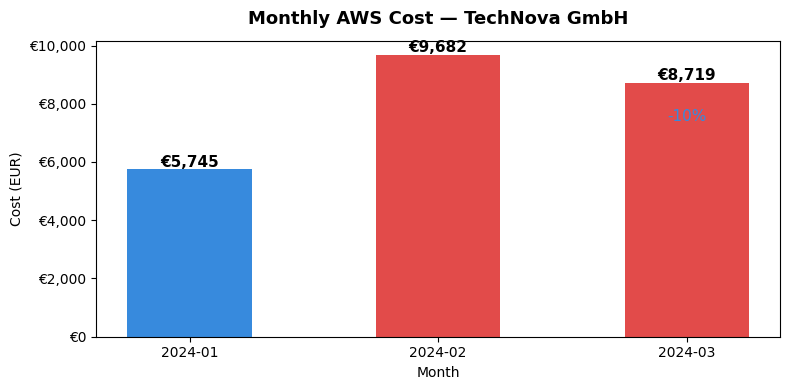

In [53]:


fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(monthly['month'], monthly['total_cost_eur'], color=['#378ADD','#E24B4A','#E24B4A'], width=0.5)

ax.set_title('Monthly AWS Cost — TechNova GmbH', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Cost (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# Annotate bars
for i, row in monthly.iterrows():
    ax.text(i, row['total_cost_eur'] + 100, f"€{row['total_cost_eur']:,.0f}",
            ha='center', fontsize=11, fontweight='bold')

# Add % change annotations
ax.annotate('+69%', xy=(1, 8000), ha='center', color='#E24B4A', fontsize=11)
ax.annotate('-10%', xy=(2, 7400), ha='center', color='#378ADD', fontsize=11)

plt.tight_layout()
plt.savefig('chart_monthly_cost.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# Analysis 2 — Cost by service
by_service = df.groupby(['billing_period','service'])['cost_eur'].sum().round(2).reset_index()
by_service = by_service.sort_values(['billing_period','cost_eur'], ascending=[True, False])
print(by_service.to_string(index=False))

billing_period            service  cost_eur
       2024-01         Amazon EC2   1978.11
       2024-01          Amazon S3   1728.60
       2024-01         Amazon RDS   1324.21
       2024-01 Amazon ElastiCache    322.26
       2024-01  AWS Data Transfer    163.28
       2024-01         Amazon EKS    136.90
       2024-01  Amazon CloudFront     90.27
       2024-01         AWS Lambda      1.24
       2024-02         Amazon EC2   4333.14
       2024-02          Amazon S3   2733.34
       2024-02         Amazon RDS   1432.41
       2024-02  AWS Data Transfer    491.70
       2024-02 Amazon ElastiCache    394.79
       2024-02         Amazon EKS    167.02
       2024-02  Amazon CloudFront    128.66
       2024-02         AWS Lambda      1.02
       2024-03         Amazon EC2   3448.43
       2024-03          Amazon S3   2851.83
       2024-03         Amazon RDS   1153.88
       2024-03  AWS Data Transfer    481.58
       2024-03 Amazon ElastiCache    461.05
       2024-03         Amazon EK

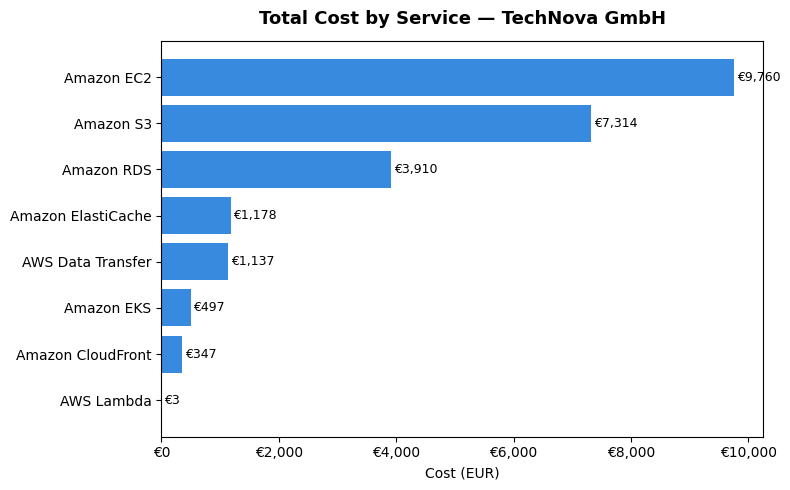

In [55]:
fig, ax = plt.subplots(figsize=(8, 5))

service_total = df.groupby('service')['cost_eur'].sum().sort_values(ascending=True)

ax.barh(service_total.index, service_total.values, color='#378ADD')

ax.set_title('Total Cost by Service — TechNova GmbH', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cost (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, val in enumerate(service_total.values):
    ax.text(val + 50, i, f'€{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_cost_by_service.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# Analysis 3 — Cost by team
by_team = df.groupby(['billing_period','tag_team'])['cost_eur'].sum().round(2).reset_index()
by_team = by_team.sort_values(['billing_period','cost_eur'], ascending=[True, False])
print(by_team.to_string(index=False))

billing_period      tag_team  cost_eur
       2024-01 data-platform   2837.16
       2024-01      untagged   1536.41
       2024-01        devops   1106.22
       2024-01       backend    265.08
       2024-02      untagged   4753.07
       2024-02       backend   1812.74
       2024-02 data-platform   1657.97
       2024-02        devops   1458.30
       2024-03 data-platform   5026.88
       2024-03       backend   1332.13
       2024-03      untagged   1253.42
       2024-03        devops   1106.13


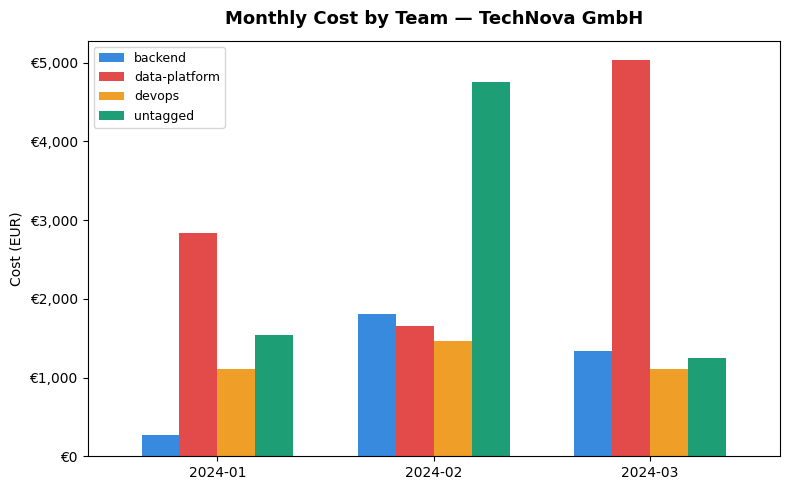

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))

team_pivot = by_team.pivot(index='billing_period', columns='tag_team', values='cost_eur').fillna(0)

team_pivot.plot(kind='bar', ax=ax, width=0.7,
                color=['#378ADD', '#E24B4A', '#EF9F27', '#1D9E75'])

ax.set_title('Monthly Cost by Team — TechNova GmbH', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chart3_cost_by_team.png', dpi=150, bbox_inches='tight')
plt.show()


In [58]:
# Analysis 4 — Untagged cost total
untagged = df[df['tag_team'] == 'untagged'].groupby('service')['cost_eur'].sum().round(2).reset_index()
untagged = untagged.sort_values('cost_eur', ascending=False)
untagged['pct_of_total'] = (untagged['cost_eur'] / df['cost_eur'].sum() * 100).round(1)
print(untagged.to_string(index=False))
print(f"\nTotal untagged cost: €{untagged['cost_eur'].sum():.2f}")
print(f"% of total spend:    {untagged['pct_of_total'].sum():.1f}%")

           service  cost_eur  pct_of_total
        Amazon EC2   2954.27          12.2
         Amazon S3   2684.90          11.1
Amazon ElastiCache    555.80           2.3
 AWS Data Transfer    491.70           2.0
        Amazon RDS    484.02           2.0
        Amazon EKS    316.92           1.3
 Amazon CloudFront     54.08           0.2
        AWS Lambda      1.21           0.0

Total untagged cost: €7542.90
% of total spend:    31.1%


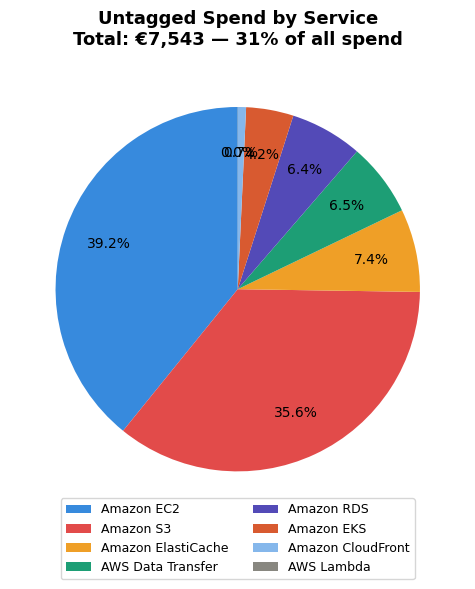

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    untagged['cost_eur'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10},
    colors=['#378ADD','#E24B4A','#EF9F27','#1D9E75','#534AB7','#D85A30','#85B7EB','#888780'],
    pctdistance=0.75
)

ax.legend(wedges, untagged['service'],
          loc='lower center',
          bbox_to_anchor=(0.5, -0.15),
          ncol=2,
          fontsize=9)

ax.set_title(f'Untagged Spend by Service\nTotal: €{untagged["cost_eur"].sum():,.0f} — 31% of all spend',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('chart4_untagged_spend.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# Analysis 5 — Idle EC2 instances (avg CPU < 10%)
ec2_usage = df[df['service'] == 'Amazon EC2'][
    ['resource_id','billing_period','tag_team','avg_cpu_utilization_pct',
     'max_cpu_utilization_pct','running_on_weekends','cost_eur']
].dropna(subset=['avg_cpu_utilization_pct'])

idle = ec2_usage[ec2_usage['avg_cpu_utilization_pct'] < 10].copy()
idle = idle.sort_values('avg_cpu_utilization_pct')

print(f"Idle instances (avg CPU < 10%): {idle['resource_id'].nunique()} instances")
print(f"Total wasted cost: €{idle['cost_eur'].sum():.2f}\n")
print(idle[['resource_id','tag_team','avg_cpu_utilization_pct',
            'running_on_weekends','cost_eur']].to_string(index=False))

Idle instances (avg CPU < 10%): 4 instances
Total wasted cost: €1813.46

resource_id      tag_team  avg_cpu_utilization_pct running_on_weekends  cost_eur
  i-00d6404       backend                      2.8                True     46.50
  i-00c5a62 data-platform                      3.1                True    615.29
  i-00d6066      untagged                      3.5                True    121.48
  i-00d6066 data-platform                      3.7                True     35.53
  i-001ed11      untagged                      4.2                True     24.49
  i-00d6404       backend                      4.7                True    270.41
  i-001ed11       backend                      4.9                True     42.48
  i-001ed11       backend                      5.2                True    131.18
  i-00d6404      untagged                      5.8                True    108.34
  i-00d6066 data-platform                      7.0                True    318.72
  i-00c5a62      untagged           

In [61]:
## Chart 5 — Idle EC2 Instances

#Idle instances = EC2 resources with average CPU utilization below 10%.
#These are running 24/7 but doing almost nothing — pure waste.
idle = df[(df['service'] == 'Amazon EC2') & 
          (df['avg_cpu_utilization_pct'] < 10)].dropna(subset=['avg_cpu_utilization_pct'])

idle_summary = idle.groupby('resource_id').agg(
    avg_cpu=('avg_cpu_utilization_pct', 'mean'),
    total_cost=('cost_eur', 'sum')
).reset_index()

print(idle_summary)

  resource_id   avg_cpu  total_cost
0   i-001ed11  4.766667      198.15
1   i-00c5a62  5.966667      714.33
2   i-00d6066  4.733333      475.73
3   i-00d6404  4.433333      425.25


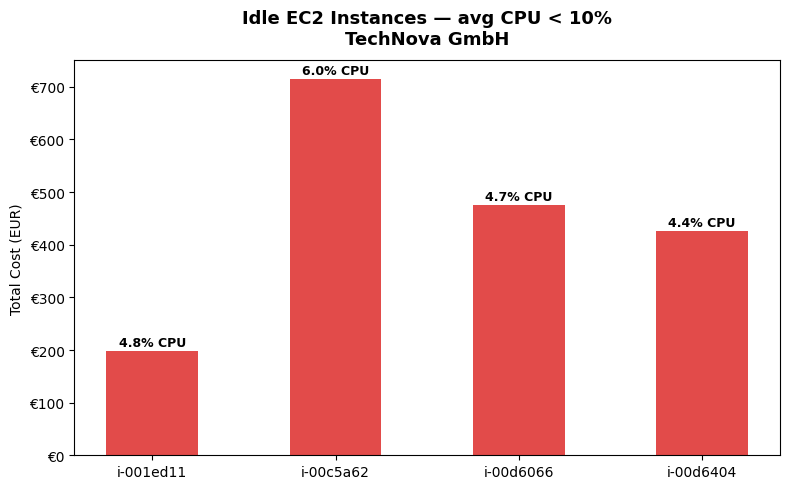

In [62]:


fig, ax = plt.subplots(figsize=(8, 5))

idle_summary = idle.groupby('resource_id').agg(
    avg_cpu=('avg_cpu_utilization_pct', 'mean'),
    total_cost=('cost_eur', 'sum')
).reset_index()

bars = ax.bar(idle_summary['resource_id'], idle_summary['total_cost'],
              color='#E24B4A', width=0.5)

ax.set_title('Idle EC2 Instances — avg CPU < 10%\nTechNova GmbH',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Total Cost (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for bar, cpu in zip(bars, idle_summary['avg_cpu']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{cpu:.1f}% CPU', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_idle_ec2.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
# Analysis 6 — Weekend waste cost
weekend_waste = ec2_usage[
    (ec2_usage['running_on_weekends'] == True) &
    (ec2_usage['avg_cpu_utilization_pct'] < 10)
].copy()

# Weekends = ~8 days/month out of ~30 = 27% of hours wasted
weekend_waste['wasted_cost_eur'] = (weekend_waste['cost_eur'] * 0.27).round(2)

print(f"Instances running idle on weekends: {weekend_waste['resource_id'].nunique()}")
print(f"Estimated weekend waste: €{weekend_waste['wasted_cost_eur'].sum():.2f}/3 months")
print(f"Projected annual waste:  €{weekend_waste['wasted_cost_eur'].sum() * 4:.2f}/year")
print()
print(weekend_waste.groupby('resource_id')[['wasted_cost_eur']].sum().sort_values('wasted_cost_eur', ascending=False).round(2))

Instances running idle on weekends: 4
Estimated weekend waste: €489.63/3 months
Projected annual waste:  €1958.52/year

             wasted_cost_eur
resource_id                 
i-00c5a62             192.87
i-00d6066             128.44
i-00d6404             114.82
i-001ed11              53.50


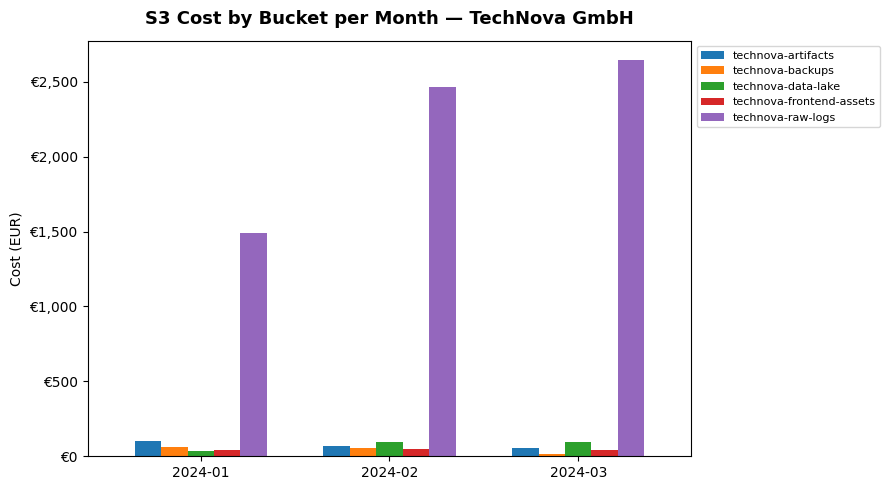

In [64]:
s3 = df[df['service'] == 'Amazon S3'].groupby(
    ['billing_period','resource_id'])['cost_eur'].sum().round(2).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))

s3_pivot = s3.pivot(index='billing_period', columns='resource_id', values='cost_eur').fillna(0)
s3_pivot.plot(kind='bar', ax=ax, width=0.7)

ax.set_title('S3 Cost by Bucket per Month — TechNova GmbH',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chart6_s3_growth.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
# Analysis 7 — Reserved Instance gap
ri_gap = df.groupby(['service','pricing_term'])['cost_eur'].sum().round(2).reset_index()
ri_gap['pct'] = (ri_gap['cost_eur'] / df['cost_eur'].sum() * 100).round(1)
print(ri_gap.sort_values('cost_eur', ascending=False).to_string(index=False))
print(f"\nTotal OnDemand spend: €{df[df['pricing_term']=='OnDemand']['cost_eur'].sum():.2f}")
print(f"Total Reserved spend: €{df[df['pricing_term']=='Reserved']['cost_eur'].sum():.2f}")

           service pricing_term  cost_eur  pct
        Amazon EC2     OnDemand   9759.68 40.4
         Amazon S3     OnDemand   7313.77 30.3
        Amazon RDS     OnDemand   3910.50 16.2
Amazon ElastiCache     OnDemand   1178.10  4.9
 AWS Data Transfer     OnDemand   1136.56  4.7
        Amazon EKS     OnDemand    496.94  2.1
 Amazon CloudFront     OnDemand    346.69  1.4
        AWS Lambda     OnDemand      3.27  0.0

Total OnDemand spend: €24145.51
Total Reserved spend: €0.00


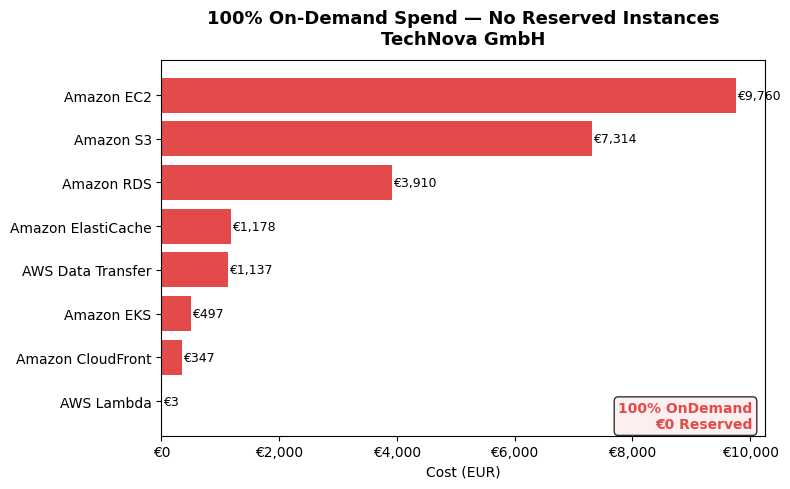

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))

service_total = df.groupby('service')['cost_eur'].sum().sort_values(ascending=True)

bars = ax.barh(service_total.index, service_total.values, color='#E24B4A')

ax.set_title('100% On-Demand Spend — No Reserved Instances\nTechNova GmbH',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cost (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, val in enumerate(service_total.values):
    ax.text(val + 20, i, f'€{val:,.0f}', va='center', fontsize=9)

ax.text(0.98, 0.02, '100% OnDemand\n€0 Reserved',
        transform=ax.transAxes, ha='right', fontsize=10,
        color='#E24B4A', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FCEBEB', alpha=0.8))

plt.tight_layout()
plt.savefig('chart7_ri_gap.png', dpi=150, bbox_inches='tight')
plt.show()

In [70]:
# Analysis 8 — S3 storage growth
s3 = df[df['service'] == 'Amazon S3'].groupby(
    ['billing_period','resource_id','tag_team'])['cost_eur'].sum().round(2).reset_index()
s3 = s3.sort_values(['resource_id','billing_period'])

print(s3.to_string(index=False))
print(f"\nTotal S3 spend: €{s3['cost_eur'].sum():.2f}")

billing_period              resource_id      tag_team  cost_eur
       2024-01       technova-artifacts data-platform    101.40
       2024-02       technova-artifacts       backend     68.17
       2024-03       technova-artifacts      untagged     56.72
       2024-01         technova-backups      untagged     58.92
       2024-02         technova-backups       backend     57.10
       2024-03         technova-backups      untagged     17.96
       2024-01       technova-data-lake      untagged     38.53
       2024-02       technova-data-lake       backend     95.30
       2024-03       technova-data-lake       backend     92.61
       2024-01 technova-frontend-assets        devops     39.00
       2024-02 technova-frontend-assets      untagged     50.91
       2024-03 technova-frontend-assets       backend     42.56
       2024-01        technova-raw-logs data-platform   1490.75
       2024-02        technova-raw-logs      untagged   2461.86
       2024-03        technova-raw-logs 

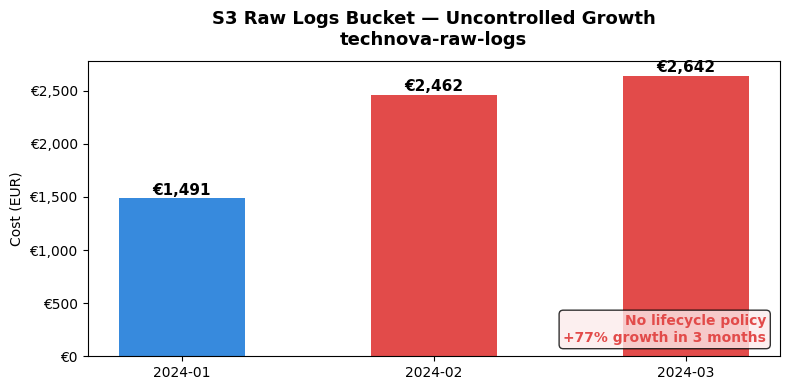

In [71]:
fig, ax = plt.subplots(figsize=(8, 4))

raw_logs = s3[s3['resource_id'] == 'technova-raw-logs']

ax.bar(raw_logs['billing_period'], raw_logs['cost_eur'],
       color=['#378ADD', '#E24B4A', '#E24B4A'], width=0.5)

ax.set_title('S3 Raw Logs Bucket — Uncontrolled Growth\ntechnova-raw-logs',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, row in raw_logs.reset_index().iterrows():
    ax.text(i, row['cost_eur'] + 30, f"€{row['cost_eur']:,.0f}",
            ha='center', fontsize=11, fontweight='bold')

ax.text(0.98, 0.05, 'No lifecycle policy\n+77% growth in 3 months',
        transform=ax.transAxes, ha='right', fontsize=10,
        color='#E24B4A', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FCEBEB', alpha=0.8))

plt.tight_layout()
plt.savefig('chart6b_raw_logs.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Analysis 9 — Savings opportunity summary
print("=" * 50)
print("SAVINGS OPPORTUNITY SUMMARY — TechNova GmbH")
print("=" * 50)

untagged_cost   = 7542.90
weekend_waste   = 489.63 * 4  # annualized
ri_saving_pct   = 0.40        # conservative 40% saving on EC2+RDS
ri_eligible     = 9759.68 + 3910.50
ri_saving       = (ri_eligible * ri_saving_pct) / 3  # per month × 3 months
s3_waste        = 6594.59 * 0.60  # 60% reducible with lifecycle policy

print(f"\n1. Untagged spend (no owner):        €{untagged_cost:>8.2f}")
print(f"   → Cannot be allocated to any team")

print(f"\n2. Weekend idle EC2 waste (annual):  €{weekend_waste:>8.2f}")
print(f"   → 4 instances running at <10% CPU on weekends")

print(f"\n3. Reserved Instance opportunity:    €{ri_saving:>8.2f}")
print(f"   → 100% OnDemand, EC2+RDS eligible for 40% RI discount")

print(f"\n4. S3 raw-logs no lifecycle policy:  €{s3_waste:>8.2f}")
print(f"   → technova-raw-logs growing +77% — needs archiving rules")

total_saving = weekend_waste + ri_saving + s3_waste
print(f"\n{'─'*50}")
print(f"Total estimated savings potential:   €{total_saving:>8.2f}")
print(f"Over 3-month period observed")
print(f"{'─'*50}")
print(f"\nCurrent 3-month spend:               €24,145.51")
print(f"Potential optimized spend:           €{24145.51 - total_saving:>8.2f}")
print(f"Potential reduction:                  {total_saving/24145.51*100:.1f}%")

SAVINGS OPPORTUNITY SUMMARY — TechNova GmbH

1. Untagged spend (no owner):        € 7542.90
   → Cannot be allocated to any team

2. Weekend idle EC2 waste (annual):  € 1958.52
   → 4 instances running at <10% CPU on weekends

3. Reserved Instance opportunity:    € 1822.69
   → 100% OnDemand, EC2+RDS eligible for 40% RI discount

4. S3 raw-logs no lifecycle policy:  € 3956.75
   → technova-raw-logs growing +77% — needs archiving rules

──────────────────────────────────────────────────
Total estimated savings potential:   € 7737.96
Over 3-month period observed
──────────────────────────────────────────────────

Current 3-month spend:               €24,145.51
Potential optimized spend:           €16407.55
Potential reduction:                  32.0%


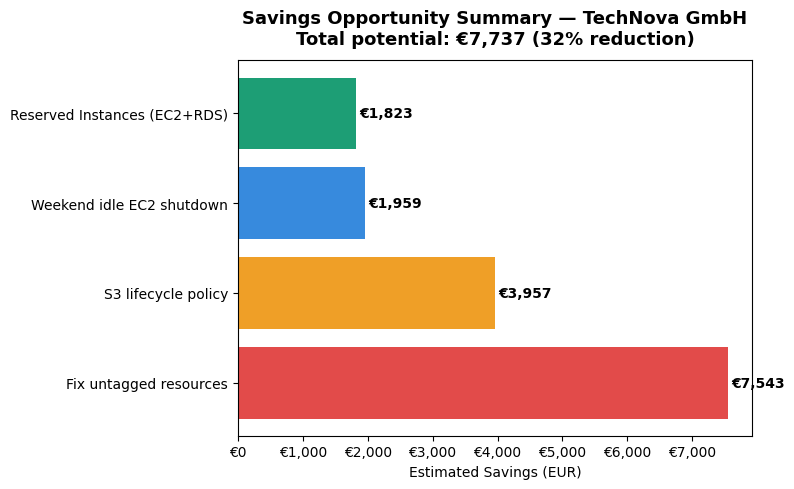

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))

savings = {
    'Fix untagged resources': 7542.90,
    'S3 lifecycle policy': 3956.75,
    'Weekend idle EC2 shutdown': 1958.52,
    'Reserved Instances (EC2+RDS)': 1822.69,
}

labels = list(savings.keys())
values = list(savings.values())

bars = ax.barh(labels, values, color=['#E24B4A','#EF9F27','#378ADD','#1D9E75'])

ax.set_title('Savings Opportunity Summary — TechNova GmbH\nTotal potential: €7,737 (32% reduction)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Estimated Savings (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, val in enumerate(values):
    ax.text(val + 50, i, f'€{val:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart9_savings_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings, Conclusions & Recommendations
### Client: TechNova GmbH | Prepared by: Cortex Reply FinOps Team | Period: Jan–Mar 2024

---

### Executive Summary
TechNova GmbH's AWS bill grew from €5,744 in January to €9,682 in February — a 69% spike
in a single month. After analyzing 3 months of billing, usage, and inventory data across
3 engineering teams, we identified 4 root causes and €7,737 in savings opportunities,
representing a 32% reduction in cloud spend.

---

### Finding 1 — 31% of Spend Is Untagged (No Owner)
- €7,542 out of €24,145 total spend cannot be allocated to any team
- EC2 and S3 are the biggest untagged services at €2,954 and €2,684 respectively
- Finance cannot do chargeback — no team is accountable for this cost
- The February spike was largely driven by untagged resources appearing suddenly

**Recommendation:** Enforce mandatory tagging policy for `team`, `environment`,
and `project` on all resources. Use AWS Config Rules to block untagged deployments.
Target: 100% tag coverage within 30 days.

---

### Finding 2 — 4 EC2 Instances Running Idle on Weekends
- 4 instances running at less than 10% average CPU utilization
- All 4 run 24/7 including weekends — nobody is using them on weekends
- Worst offender: i-00c5a62 (data-platform) at 3.1% avg CPU costing €615 over 3 months
- Estimated annual waste: €1,958/year

**Recommendation:** Implement auto-shutdown schedules for dev/test instances
outside business hours (Mon–Fri 08:00–20:00 CET). Use AWS Instance Scheduler.
Estimated saving: €1,958/year.

---

### Finding 3 — Zero Reserved Instance Coverage (100% On-Demand)
- Every single service is billed at full On-Demand price
- EC2 alone costs €9,759 over 3 months — all at the most expensive rate
- EC2 + RDS combined: €13,670 over 3 months
- Reserved Instances for steady workloads offer 40–60% discount

**Recommendation:** Purchase 1-year Reserved Instances for stable EC2 and RDS workloads.
Start with the top 5 highest-cost instances. Conservative estimate of 40% saving
on EC2+RDS = €1,822 over the same 3-month period.

---

### Finding 4 — S3 Raw Logs Bucket Growing 77% with No Lifecycle Policy
- technova-raw-logs is the single biggest S3 bucket at €6,594 over 3 months
- Growing every month: Jan €1,490 → Feb €2,461 → Mar €2,641
- No archiving, no cleanup, no lifecycle rules — it will keep growing indefinitely
- Accounts for 90% of all S3 spend

**Recommendation:** Implement S3 lifecycle policy immediately:
- Move logs older than 30 days to S3 Glacier (90% cheaper)
- Delete logs older than 90 days unless legally required
- Estimated saving: €3,956 over next 3 months

---

### Savings Summary

| # | Finding                        | 3-Month Saving | Action                        |
|---|-------------------------------|----------------|-------------------------------|
| 1 | Untagged resources             | €7,542         | Enforce tagging policy        |
| 2 | Idle EC2 weekend waste         | €1,958/year    | Auto-shutdown scheduler       |
| 3 | Reserved Instance gap          | €1,822         | Purchase 1-year RIs           |
| 4 | S3 raw-logs no lifecycle       | €3,956         | Add S3 lifecycle rules        |
| | **Total**                     | **€7,737**     | **32% cost reduction**        |

---

### Conclusion
TechNova GmbH is in the early crawl stage of FinOps maturity. The cost spike was not
caused by business growth — it was caused by lack of governance, visibility, and
cloud cost awareness. None of these findings require architectural changes.
All 4 recommendations can be implemented within 2–4 weeks with minimal engineering effort.

The immediate priority is tagging — without it, none of the other optimizations
can be measured or attributed to a team. Once tagging is enforced, TechNova will
have the visibility needed to move from the Inform phase into the Optimize phase
of the FinOps lifecycle.

In [73]:
streamlit run dashboard.py

SyntaxError: invalid syntax (512221001.py, line 1)